In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Libraries imported')


Libraries imported


# Load Dataset (Iris)

In [29]:
import pandas as pd
df_long = pd.read_csv('/content/california_housing_test (1).csv')
display(df_long.head())


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27,3885,661,1537,606,6.6085,344700
1,-118.30,34.26,43,1510,310,809,277,3.5990,176500
2,-117.81,33.78,27,3589,507,1484,495,5.7934,270500
3,-118.36,33.82,28,67,15,49,11,6.1359,330000
4,-119.67,36.33,19,1241,244,850,237,2.9375,81700


# Explore Dataset

In [30]:
print('Shape:', df_long.shape)
print('Classes:', df_long['longitude'].unique())
df_long.describe()

Shape: (499, 9)
Classes: [-122.05 -118.3  -117.81 -118.36 -119.67 -119.56 -121.43 -120.65 -122.84
 -118.02 -118.24 -119.12 -121.93 -117.03 -117.97 -117.99 -120.81 -121.2
 -118.88 -122.59 -122.15 -121.37 -118.16 -122.2  -117.28 -118.03 -122.42
 -118.39 -118.45 -118.48 -119.35 -121.13 -118.08 -118.32 -118.11 -122.53
 -118.05 -119.01 -119.32 -116.92 -118.06 -117.27 -118.23 -117.24 -121.91
 -118.29 -121.35 -120.99 -119.42 -122.21 -118.17 -117.9  -121.42 -118.77
 -121.82 -122.29 -121.78 -118.41 -121.67 -118.   -117.22 -121.08 -117.53
 -117.46 -121.92 -118.2  -123.79 -120.79 -121.89 -118.43 -118.75 -122.47
 -120.69 -118.28 -118.44 -121.99 -121.02 -119.85 -123.52 -122.4  -118.13
 -122.   -117.5  -122.22 -119.82 -120.21 -120.97 -121.19 -122.23 -121.31
 -117.25 -118.26 -119.39 -121.51 -119.18 -118.18 -122.43 -117.93 -124.16
 -117.95 -116.97 -118.85 -117.73 -122.07 -117.18 -121.96 -121.74 -118.21
 -121.9  -118.19 -120.93 -122.02 -117.19 -118.14 -119.76 -122.34 -122.45
 -122.04 -117.39 -122.25 -1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,-119.562926,35.606673,28.991984,2573.765531,527.861723,1403.839679,485.466934,3.791752,201843.328657
std,1.982282,2.087588,12.123856,2165.030033,417.076605,1009.422119,350.606142,1.886359,109524.527773
min,-124.160000,32.580000,2.000000,67.000000,15.000000,49.000000,11.000000,0.499900,44400.000000
25%,-121.755000,33.930000,19.000000,1437.000000,294.000000,777.500000,274.000000,2.568200,121200.000000
50%,-118.450000,34.240000,30.000000,2036.000000,428.000000,1121.000000,396.000000,3.416700,174300.000000
75%,-118.050000,37.640000,38.000000,3046.000000,620.500000,1719.500000,586.500000,4.562500,258650.000000
max,-114.980000,41.010000,52.000000,24121.000000,4522.000000,8768.000000,3293.000000,15.000100,500001.000000


# Select Features (two for visualization)

In [31]:
X = df_long[['longitude','latitude']]
y = df_long['total_rooms']
y.head()

,total_rooms
0,3885
1,1510
2,3589
3,67
4,1241


# Train–Test Split (70:30)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Training size: (349, 2)
Testing size: (150, 2)


# Build SVM Model (Linear Kernel)

In [33]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
print('Model trained')

Model trained


# Predict Test Data

In [34]:
y_pred = svm.predict(X_test)
list(y_pred)[:10]

[np.int64(1510),
 np.int64(2034),
 np.int64(1808),
 np.int64(1510),
 np.int64(2034),
 np.int64(2290),
 np.int64(2290),
 np.int64(1510),
 np.int64(2290),
 np.int64(1510)]

# Compare Predictions (Correct / Wrong)

In [35]:
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
results['Status'] = results.apply(lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1)
results.head(20)

,Actual,Predicted,Status
0,2034,1510,Wrong
1,2400,2034,Wrong
2,2936,1808,Wrong
3,2757,1510,Wrong
4,1932,2034,Wrong
5,1508,2290,Wrong
6,3907,2290,Wrong
7,1287,1510,Wrong
8,2789,2290,Wrong
9,2402,1510,Wrong


# Evaluate Model Performance

In [36]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.0

Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
               precision    recall  f1-score   support

         142       0.00      0.00      0.00       1.0
         161       0.00      0.00      0.00       1.0
         414       0.00      0.00      0.00       1.0
         570       0.00      0.00      0.00       1.0
         593       0.00      0.00      0.00       1.0
         639       0.00      0.00      0.00       1.0
         698       0.00      0.00      0.00       1.0
         721       0.00      0.00      0.00       1.0
         736       0.00      0.00      0.00       2.0
         954       0.00      0.00      0.00       1.0
         963       0.00      0.00      0.00       1.0
         978       0.00      0.00      0.00       1.0
         984       0.00      0.00      0.00       1.0
        1018       0.00      0.00      0.00       1.0
        10

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Visualize Decision Boundary

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


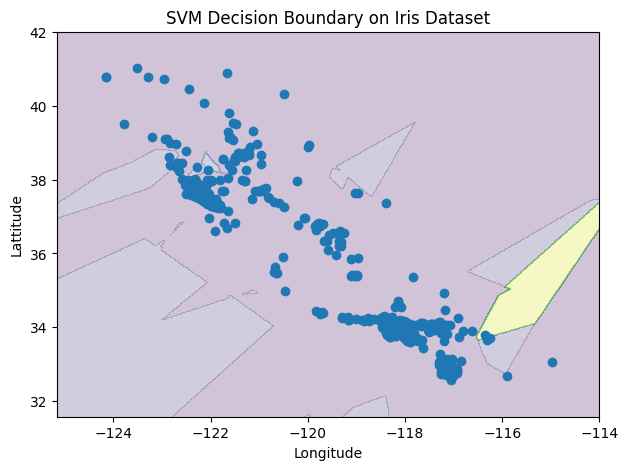

In [17]:
x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
y_min, y_max = X.iloc[:,1].min()-1, X.iloc[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel('Longitude')
plt.ylabel('Lattitude')
plt.title('SVM Decision Boundary on Iris Dataset')
plt.show()



# **Conclusion**

In this program, we implemented a Support Vector Machine (SVM) classifier to classify the Iris dataset using Petal Length and Petal Width. By visualizing the decision boundaries, we observed how SVM separates the different flower species in a two-dimensional feature space.

Key takeaways:

SVM effectively separates classes even when they are not linearly separable by finding the optimal margin.

The decision boundary visualization helps us understand the model’s behavior and where misclassifications may occur.

Using only two features simplifies visualization but still provides good classification accuracy for the Iris dataset.

This approach can be extended to other datasets or more features, though visualization becomes challenging beyond 2D.